# Riyadh / Grocery Demand Forecast

<a href="https://colab.research.google.com/github/manaralbader/retail-demand-forecast/blob/main/riyadh-grocery-demand-forecast.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>

In [1]:
import subprocess, sys

def _pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

_pip_install("pandas", "numpy", "matplotlib", "statsmodels", "scikit-learn", "lightgbm")

import pathlib
import urllib.request

REPO = "manaralbader/retail-demand-forecast"
BRANCH = "main"

def fetch(rel_path: str) -> str:
    """Find rel_path in a local repo checkout, or download it from GitHub
    if it isn't there (a fresh Colab runtime with nothing cloned)."""
    for candidate in (rel_path, f"../{rel_path}"):
        if pathlib.Path(candidate).exists():
            return candidate
    dest = pathlib.Path(pathlib.Path(rel_path).name)
    if not dest.exists():
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{rel_path}"
        urllib.request.urlretrieve(url, dest)
    return str(dest)

sys.path.insert(0, str(pathlib.Path(fetch("common/metrics.py")).parent))
from metrics import mae, rmse, mase, coverage, interval_width
sys.path.insert(0, str(pathlib.Path(fetch("common/backtest.py")).parent))
from backtest import expanding_window_splits, run_backtest, seasonal_naive_forecast

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

RNG_SEED = 20260912
np.random.seed(RNG_SEED)

## 1. Time Series Structure & Diagnostics

Riyadh / Grocery, daily units sold, 2023–2025.


1096 rows, 2023-01-01 to 2025-12-31
expected 1096 calendar days -> no gaps
count    1096.000000
mean      669.549270
std       206.684648
min       397.000000
25%       534.750000
50%       626.000000
75%       743.000000
max      2357.000000
Name: units_sold, dtype: float64


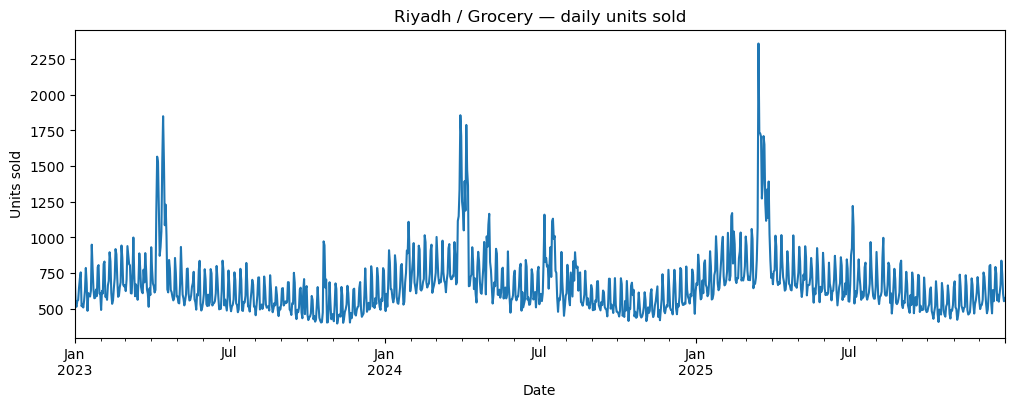

In [2]:
df = pd.read_csv(fetch("data/retail_demand.csv"), parse_dates=["date"])
riyadh_grocery = df[(df["region"] == "Riyadh") & (df["category"] == "Grocery")].copy()
riyadh_grocery = riyadh_grocery.sort_values("date").set_index("date")
y = riyadh_grocery["units_sold"]

expected_days = (y.index.max() - y.index.min()).days + 1
print(f"{len(y)} rows, {y.index.min().date()} to {y.index.max().date()}")
print(f"expected {expected_days} calendar days -> {'no gaps' if expected_days == len(y) else 'GAPS PRESENT, need to investigate'}")

y = y.asfreq("D")  # lock in a daily frequency now that we've confirmed there are no gaps
print(y.describe())

fig, ax = plt.subplots(figsize=(12, 4))
y.plot(ax=ax)
ax.set_title("Riyadh / Grocery — daily units sold")
ax.set_xlabel("Date")
ax.set_ylabel("Units sold")
plt.show()

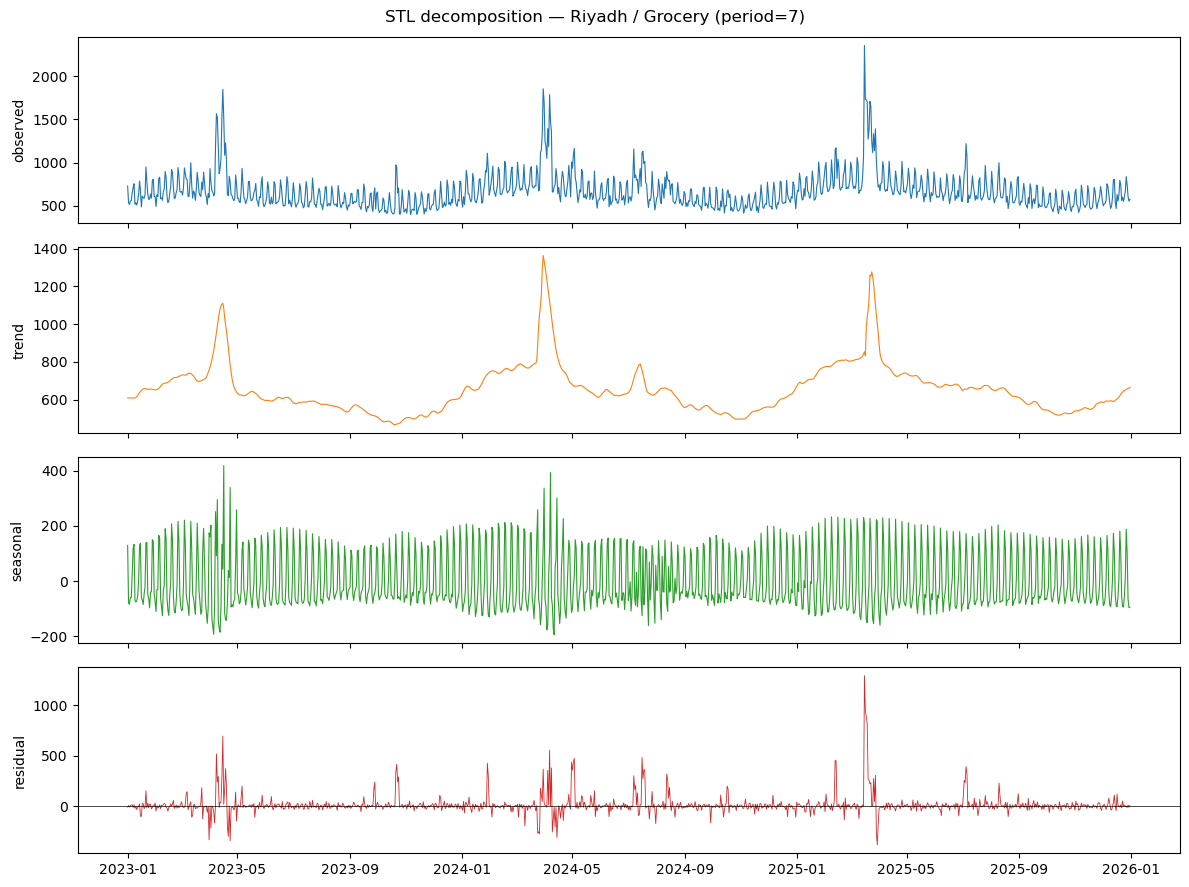

residual std: 104.68739531431723
largest 5 |residual| days:
date
2025-03-16    1293.844161
2025-03-17     942.499865
2025-03-18     885.541233
2025-03-19     819.675148
2023-04-15     693.547435
Name: resid, dtype: float64


In [3]:
from statsmodels.tsa.seasonal import STL

stl = STL(y, period=7, robust=True)
decomp = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(y.index, y.values, linewidth=0.8)
axes[0].set_ylabel("observed")
axes[1].plot(y.index, decomp.trend, linewidth=0.8, color="tab:orange")
axes[1].set_ylabel("trend")
axes[2].plot(y.index, decomp.seasonal, linewidth=0.8, color="tab:green")
axes[2].set_ylabel("seasonal")
axes[3].plot(y.index, decomp.resid, linewidth=0.6, color="tab:red")
axes[3].set_ylabel("residual")
axes[3].axhline(0, color="black", linewidth=0.5)
fig.suptitle("STL decomposition — Riyadh / Grocery (period=7)")
plt.tight_layout()
plt.show()

print("residual std:", np.std(decomp.resid))
print("largest 5 |residual| days:")
print(decomp.resid.abs().sort_values(ascending=False).head(5))

In [4]:
trend_start, trend_end = decomp.trend.dropna().iloc[0], decomp.trend.dropna().iloc[-1]
trend_change_pct = (trend_end - trend_start) / trend_start * 100

seasonal_amplitude = decomp.seasonal.iloc[:7].max() - decomp.seasonal.iloc[:7].min()

resid_share = decomp.resid.std() / y.std() * 100

print(f"trend: {trend_start:.1f} -> {trend_end:.1f} ({trend_change_pct:+.1f}% over the full period)")
print(f"weekly seasonal amplitude (peak-to-trough within one week): {seasonal_amplitude:.1f} units")
print(f"residual std as % of raw series std: {resid_share:.1f}%")

trend: 609.0 -> 664.1 (+9.0% over the full period)
weekly seasonal amplitude (peak-to-trough within one week): 213.4 units
residual std as % of raw series std: 50.7%


Trend is mild — +9% over three years, drift more than signal. Weekly seasonality is the strongest component: 213 units peak-to-trough, about a third of the mean level. The residual is large relative to the series (51% of its std), and the biggest misses aren't scattered noise — the four largest are consecutive days in March 2025, which looks like a promo shock STL folded into the residual rather than the seasonal term (expected, since STL's seasonal period is fixed at 7 and can't absorb a one-off event).


### Stationarity: ACF, PACF, and the ADF test

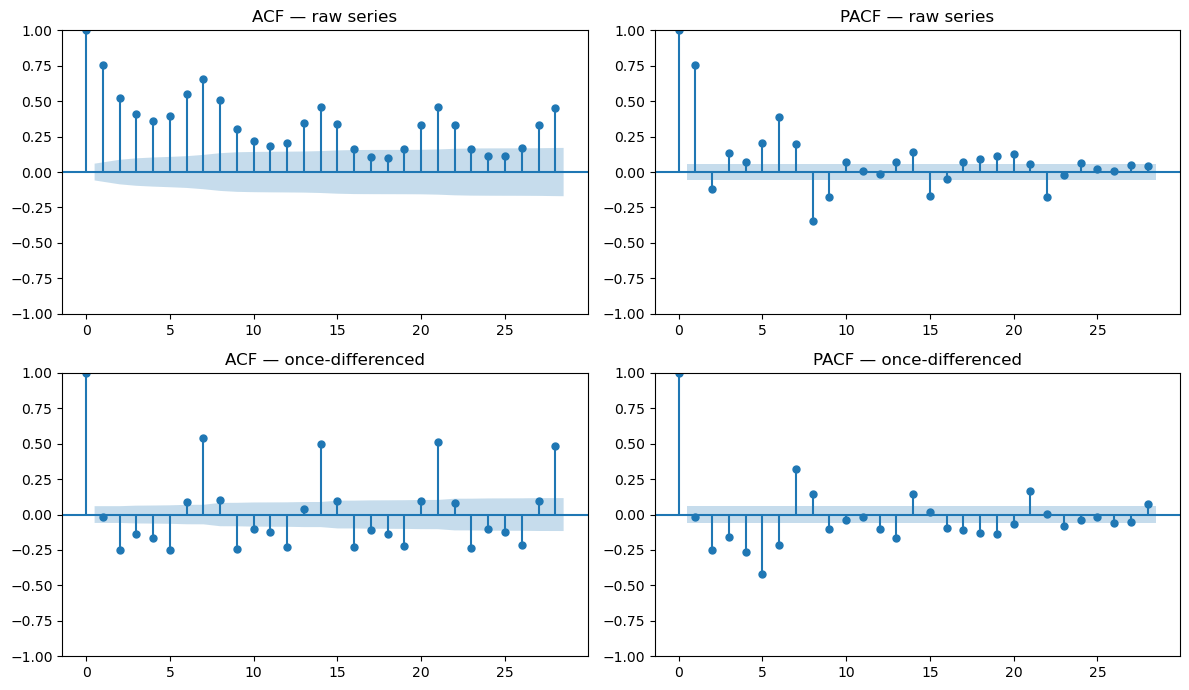

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

diffed = y.diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_acf(y, lags=28, ax=axes[0, 0])
axes[0, 0].set_title("ACF — raw series")
plot_pacf(y, lags=28, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF — raw series")
plot_acf(diffed, lags=28, ax=axes[1, 0])
axes[1, 0].set_title("ACF — once-differenced")
plot_pacf(diffed, lags=28, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF — once-differenced")
plt.tight_layout()
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller

def report_adf(series, label):
    """Run the ADF test on `series`, print stat/p-value/critical values, return the p-value."""
    result = adfuller(series.dropna(), autolag="AIC", result_object=True)
    print(f"{label}")
    print(f"  ADF statistic: {result.statistic:.4f}")
    print(f"  p-value:       {result.pvalue:.6f}")
    print(f"  used lags:     {result.lags}")
    for level, cv in result.critical_values.items():
        print(f"  critical value ({level}): {cv:.4f}")
    verdict = "stationary (reject the unit-root null)" if result.pvalue < 0.05 else "NON-stationary (fail to reject the unit-root null)"
    print(f"  => {verdict}\n")
    return result.pvalue

pvalue_raw = report_adf(y, "Raw series")
pvalue_diff = report_adf(diffed, "Once-differenced series")

Raw series
  ADF statistic: -3.8721
  p-value:       0.002250
  used lags:     21
  critical value (1%): -3.4365
  critical value (5%): -2.8642
  critical value (10%): -2.5682
  => stationary (reject the unit-root null)

Once-differenced series
  ADF statistic: -9.8473
  p-value:       0.000000
  used lags:     22
  critical value (1%): -3.4365
  critical value (5%): -2.8642
  critical value (10%): -2.5682
  => stationary (reject the unit-root null)



PACF cuts off sharply after lag 1 with a clear spike at lag 7, the seasonal-AR signature of a weekly cycle; ACF decays slowly, typical of a series that's autocorrelated but not obviously non-stationary. The ADF test agrees: both the raw and differenced series reject the unit-root null (p=0.0023 raw, p≈0 differenced), so strictly the raw series is already stationary and differencing isn't required. That's consistent with the weak trend above — a slow +9% drift over three years isn't enough non-stationarity for ADF to flag. The SARIMA below is fit with d=0 on that basis, leaving the seasonal AR term to carry the weekly structure.


## 2. Classical Model — SARIMA

Starting point: SARIMA(1,0,1)(1,0,1)[7] — an AR/MA pair for the lag-1 autocorrelation the PACF showed, a seasonal (1,0,1) pair for the weekly cycle, d=0 per the ADF result above.


In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    y,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7),
    trend="c",
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                        units_sold   No. Observations:                 1096
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -6752.965
Date:                           Tue, 22 Sep 2026   AIC                          13517.930
Time:                                   11:53:19   BIC                          13547.926
Sample:                               01-01-2023   HQIC                         13529.280
                                    - 12-31-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    166.1466     17.527      9.480      0.000     131.795     200.498
ar.L1          0.5753      0.021     27.366

C:\Users\Manar Albader\miniconda3\envs\ml\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


The seasonal MA term (`ma.S.L7`, p=0.465) wasn't significant and the fit threw a convergence warning, so it's dropped — `seasonal_order=(1,0,0,7)` instead of `(1,0,1,7)`. AIC improves (13517.9 → 13466.3), every remaining term is significant at the 5% level, and the fit converges cleanly. Final model: SARIMA(1,0,1)(1,0,0)[7].


In [8]:
sarima_model = SARIMAX(
    y,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 0, 7),
    trend="c",
)
sarima_fit = sarima_model.fit(disp=False, maxiter=200)
print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                         units_sold   No. Observations:                 1096
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 7)   Log Likelihood               -6728.162
Date:                            Tue, 22 Sep 2026   AIC                          13466.323
Time:                                    11:53:20   BIC                          13491.320
Sample:                                01-01-2023   HQIC                         13475.782
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     77.2754      7.717     10.014      0.000      62.151      92.400
ar.L1          0.7306      0.019   

In [9]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = sarima_fit.resid

lb_results = acorr_ljungbox(residuals, lags=[7, 14, 21, 28], return_df=True)
print(lb_results)

       lb_stat     lb_pvalue
7    52.038817  5.736611e-09
14   85.944315  2.201600e-12
21  141.722903  6.475604e-20
28  159.054040  2.821961e-20


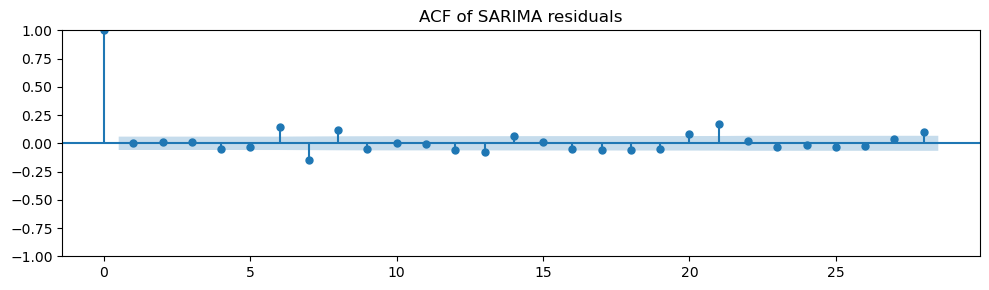

largest |residual ACF|, lags 1-28: 0.17492399220787888
at lag: 21


In [10]:
from statsmodels.tsa.stattools import acf

fig, ax = plt.subplots(figsize=(10, 3))
plot_acf(residuals, lags=28, ax=ax)
ax.set_title("ACF of SARIMA residuals")
plt.tight_layout()
plt.show()

resid_acf = acf(residuals, nlags=28)[1:]  # drop lag 0 (always 1.0)
print("largest |residual ACF|, lags 1-28:", np.abs(resid_acf).max())
print("at lag:", np.argmax(np.abs(resid_acf)) + 1)

The Ljung-Box row inside the model summary (lag 1 only) looks clean — Q=0.00, p=0.99. That's a weak check, though. Testing lags 7/14/21/28 directly tells a different story: p-values from 6e-9 to 3e-20, rejecting white noise at every one, and the residual ACF's largest remaining spike (0.17) sits at lag 21. So the residuals aren't clean — there's autocorrelation this order hasn't captured, most likely a slower cycle a (1,0,0)[7] seasonal term isn't built to catch. Worth flagging rather than stopping at the lag-1 check.


### Addressing the leftover structure: annual Fourier terms

The dataset brief calls out weekly *and* yearly seasonality, but the SARIMA above only models the weekly cycle — a period-365 seasonal term isn't practical to fit directly. Two sine/cosine pairs at the annual period, added as exogenous regressors, are a cheap way to let the model see that cycle without it.


In [11]:
def annual_fourier(index, order=2, period=365.25):
    """Sine/cosine pairs at the annual period, keyed off calendar day-of-year so
    they stay correct regardless of which rows a fold happens to start on."""
    doy = index.dayofyear.values.astype(float)
    cols = {}
    for k in range(1, order + 1):
        cols[f"annual_sin_{k}"] = np.sin(2 * np.pi * k * doy / period)
        cols[f"annual_cos_{k}"] = np.cos(2 * np.pi * k * doy / period)
    return pd.DataFrame(cols, index=index)

exog_full = annual_fourier(y.index, order=2)

sarima_model = SARIMAX(
    y,
    exog=exog_full,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 0, 7),
    trend="c",
)
sarima_fit = sarima_model.fit(disp=False, maxiter=200)
print(sarima_fit.summary())


                                     SARIMAX Results                                      
Dep. Variable:                         units_sold   No. Observations:                 1096
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 7)   Log Likelihood               -6717.101
Date:                            Tue, 22 Sep 2026   AIC                          13452.201
Time:                                    11:53:22   BIC                          13497.196
Sample:                                01-01-2023   HQIC                         13469.226
                                     - 12-31-2025                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
intercept      100.2973      8.999     11.146      0.000      82.660     117.934
annual_sin_1   145.8364     3

In [12]:
residuals = sarima_fit.resid

lb_results = acorr_ljungbox(residuals, lags=[7, 14, 21, 28], return_df=True)
print(lb_results)

resid_acf = acf(residuals, nlags=28)[1:]
print("largest |residual ACF|, lags 1-28:", np.abs(resid_acf).max())
print("at lag:", np.argmax(np.abs(resid_acf)) + 1)


       lb_stat     lb_pvalue
7    45.286293  1.203283e-07
14   88.941652  6.011284e-13
21  155.340664  1.686910e-22
28  178.766296  6.618427e-24
largest |residual ACF|, lags 1-28: 0.1710956274880318
at lag: 21


Modest, honest result: AIC improves again (13466 → 13452), and `annual_sin_1` is genuinely significant (coef=145.8, p<0.001) — there's a real annual signal there. But Ljung-Box still rejects white noise at every lag tested, and the lag-21 spike barely moves (0.175 → 0.171). So this fixes part of the story, not all of it. Whatever's left at lag 21 isn't the smooth annual cycle Fourier terms are built to catch — more likely the irregular promo shocks flagged in section 1 (STL's biggest residuals were a single 4-day run in March 2025), which no periodic term, weekly or annual, is built to catch. Worth stopping here rather than bolting on more Fourier pairs chasing a residual that isn't actually periodic — and worth checking section 5 before calling this an improvement: the backtest verdict on these extra parameters is not what the AIC suggests.


## 3. ML/GBM Model — LightGBM with Engineered Features


In [13]:
feat = pd.DataFrame({"y": y})

for lag in [1, 2, 7, 14, 21, 28]:
    feat[f"lag_{lag}"] = feat["y"].shift(lag)

for window in [7, 14, 28]:
    feat[f"roll_mean_{window}"] = feat["y"].shift(1).rolling(window).mean()
    feat[f"roll_std_{window}"] = feat["y"].shift(1).rolling(window).std()

feat["dayofweek"] = feat.index.dayofweek
feat["day"] = feat.index.day
feat["month"] = feat.index.month
feat["dayofyear"] = feat.index.dayofyear
feat["weekofyear"] = feat.index.isocalendar().week.astype(int)

feat = feat.dropna()

print(f"{len(feat)} rows remain after dropping warm-up NaNs (lost {len(y) - len(feat)} rows to the longest 28-day lag/window)")
feat.head()

1068 rows remain after dropping warm-up NaNs (lost 28 rows to the longest 28-day lag/window)


,y,lag_1,lag_2,lag_7,lag_14,lag_21,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_28,roll_std_28,dayofweek,day,month,dayofyear,weekofyear
date,,,,,,,,,,,,,,,,,,
2023-01-29,806.0,792.0,589.0,779.0,680.0,755.0,728.0,654.714286,92.977980,651.071429,117.179326,630.607143,108.173845,6,29,1,29,4
2023-01-30,607.0,806.0,792.0,637.0,486.0,518.0,535.0,658.571429,99.335890,660.071429,124.200498,633.392857,111.720995,0,30,1,30,5
2023-01-31,607.0,607.0,806.0,574.0,610.0,534.0,514.0,654.285714,101.053970,668.714286,115.026705,635.964286,110.190570,1,31,1,31,5
2023-02-01,492.0,607.0,607.0,577.0,595.0,509.0,555.0,659.000000,97.387542,668.500000,115.147230,639.285714,107.752754,2,1,2,32,5
2023-02-02,626.0,492.0,607.0,635.0,586.0,558.0,561.0,646.857143,113.312883,661.142857,123.212672,637.035714,110.207710,3,2,2,33,5


In [14]:
LAG_LIST = [1, 2, 7, 14, 21, 28]
ROLL_WINDOWS = [7, 14, 28]
FEATURE_COLS = (
    [f"lag_{k}" for k in LAG_LIST]
    + [f"roll_mean_{w}" for w in ROLL_WINDOWS]
    + [f"roll_std_{w}" for w in ROLL_WINDOWS]
    + ["dayofweek", "day", "month", "dayofyear", "weekofyear"]
)

def build_features(series: pd.Series) -> pd.DataFrame:
    """Lag, rolling-window, and calendar features for one series. Every lag/rolling value
    is shifted so the row for day t never sees day t's own target."""
    f = pd.DataFrame({"y": series})
    for lag in LAG_LIST:
        f[f"lag_{lag}"] = f["y"].shift(lag)
    for window in ROLL_WINDOWS:
        f[f"roll_mean_{window}"] = f["y"].shift(1).rolling(window).mean()
        f[f"roll_std_{window}"] = f["y"].shift(1).rolling(window).std()
    f["dayofweek"] = f.index.dayofweek
    f["day"] = f.index.day
    f["month"] = f.index.month
    f["dayofyear"] = f.index.dayofyear
    f["weekofyear"] = f.index.isocalendar().week.astype(int)
    return f

# sanity check: should match what Cell 15 showed
feat_check = build_features(y).dropna()
print(f"{len(feat_check)} rows, {len(FEATURE_COLS)} feature columns")
assert len(feat_check) == 1068

1068 rows, 17 feature columns


Every rolling feature is built on `.shift(1)` before the window, so the row for day *t* only sees data through *t-1*, never *t* itself — same reasoning for the lags (minimum lag is 1). The multi-step forecast is recursive: each prediction gets appended to history to build the next step's features, so there's no peeking at real future actuals at any horizon either.


In [15]:
import lightgbm as lgb

def train_lgbm(y_train: pd.Series) -> lgb.LGBMRegressor:
    """Fit a LightGBM regressor on one training series' engineered features."""
    train_feat = build_features(y_train).dropna()
    model = lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=15,
        random_state=RNG_SEED,
        verbosity=-1,
    )
    model.fit(train_feat[FEATURE_COLS], train_feat["y"])
    return model

def recursive_forecast(model: lgb.LGBMRegressor, history: pd.Series, horizon: int) -> np.ndarray:
    """Forecast `horizon` steps by predicting one day at a time and feeding each
    prediction back into history for the next day's lag/rolling features."""
    history = history.copy()
    preds = []
    for _ in range(horizon):
        next_date = history.index[-1] + pd.Timedelta(days=1)
        row = build_features(pd.concat([history, pd.Series([np.nan], index=[next_date])])).iloc[[-1]]
        pred = model.predict(row[FEATURE_COLS])[0]
        preds.append(pred)
        history.loc[next_date] = pred
    return np.array(preds)

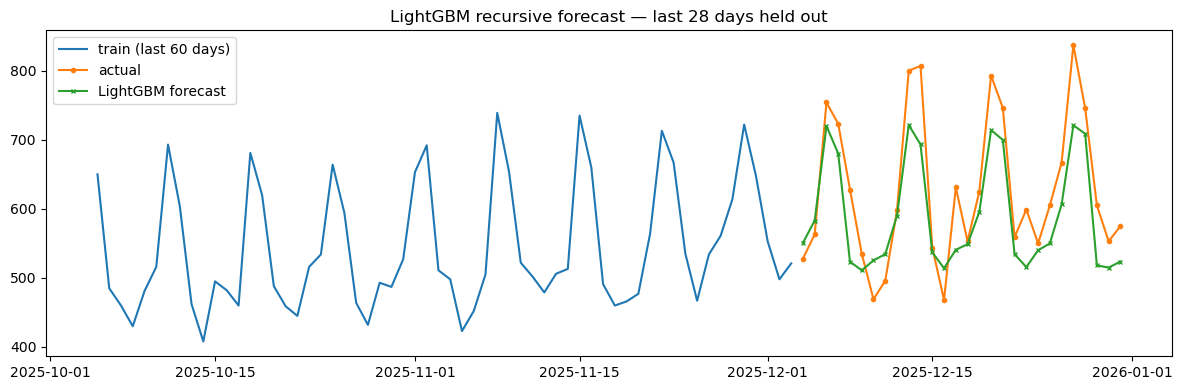

demo MAE: 50.30123172676141
demo RMSE: 59.66472798468656


In [16]:
test_horizon = 28
train_demo = y.iloc[:-test_horizon]
test_demo = y.iloc[-test_horizon:]

demo_model = train_lgbm(train_demo)
demo_preds = recursive_forecast(demo_model, train_demo, test_horizon)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_demo.index[-60:], train_demo.values[-60:], label="train (last 60 days)")
ax.plot(test_demo.index, test_demo.values, label="actual", marker="o", markersize=3)
ax.plot(test_demo.index, demo_preds, label="LightGBM forecast", marker="x", markersize=3)
ax.legend()
ax.set_title("LightGBM recursive forecast — last 28 days held out")
plt.tight_layout()
plt.show()

print("demo MAE:", mae(test_demo.values, demo_preds))
print("demo RMSE:", rmse(test_demo.values, demo_preds))

(Single 28-day holdout — just a sanity check on the pipeline before the real backtest below.)


lag_1          449
roll_mean_7    229
lag_14         204
lag_2          194
lag_28         181
dayofyear      176
roll_std_7     175
lag_21         172
dtype: int32


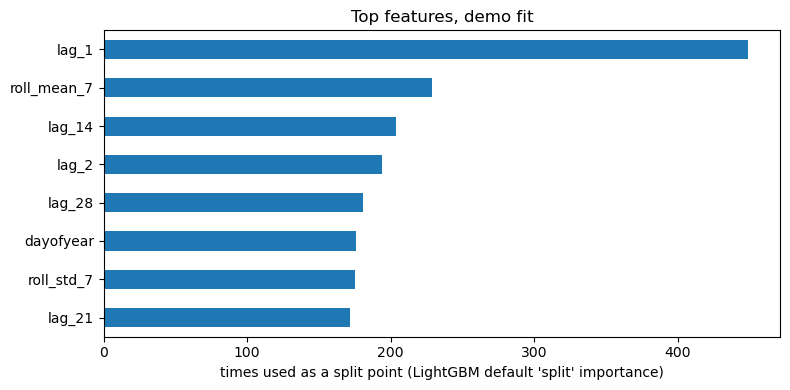

In [17]:
importances = pd.Series(demo_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print(importances.head(8))

fig, ax = plt.subplots(figsize=(8, 4))
importances.head(8).iloc[::-1].plot.barh(ax=ax)
ax.set_xlabel("times used as a split point (LightGBM default 'split' importance)")
ax.set_title("Top features, demo fit")
plt.tight_layout()
plt.show()


`lag_1` dominates by a wide margin (449 splits vs. the next-highest 229) — yesterday's value alone carries more signal than any single engineered window. The rolling and longer lags (`roll_mean_7`, `lag_14`, `lag_2`, `lag_28`) fill in the next tier, and `dayofyear` cracks the top 8 — LightGBM finds a use for the annual calendar position on its own, without needing an explicit Fourier term the way SARIMA did in section 2.


## 4. Walk-Forward Backtest

5-fold expanding window (`min_train_size=365`, `horizon=14`). Expanding, not rolling, because this series has no structural break to discard — unlike `workforce_demand.csv` — so there's no reason to throw away early history; more data only helps SARIMA's seasonal estimate and LightGBM's lag features. Fold 0's actual training size comes out to 1026 days, well above the 365 floor — that floor is a minimum, not a target, and five 14-day folds only reserve 70 of the 1096 days for testing.


In [18]:
splits = expanding_window_splits(n=len(y), n_folds=5, horizon=14, min_train_size=365)
for train_slice, test_slice in splits:
    assert train_slice.stop <= test_slice.start, "fold leaks test-period rows into training"
print(f"{len(splits)} folds, verified no fold's training window overlaps its test window")
print(f"fold 0 train size = {splits[0][0].stop}, last fold test window = {splits[-1][1]}")

def fit_predict_baseline(y_train, horizon):
    """Backtest adapter: seasonal-naive forecast, period=7."""
    return seasonal_naive_forecast(y_train, horizon, period=7)

def fit_predict_sarima(y_train, horizon):
    """Backtest adapter: SARIMA(1,0,1)(1,0,0)[7] with annual Fourier exog (see section 2).
    Expanding window means y_train is always y[:len(y_train)], so dates line up positionally."""
    dates_train = y.index[:len(y_train)]
    dates_future = y.index[len(y_train):len(y_train) + horizon]
    model = SARIMAX(
        y_train,
        exog=annual_fourier(dates_train),
        order=(1, 0, 1),
        seasonal_order=(1, 0, 0, 7),
        trend="c",
    )
    fit = model.fit(disp=False, maxiter=200)
    return fit.get_forecast(steps=horizon, exog=annual_fourier(dates_future)).predicted_mean

def fit_predict_lgbm(y_train, horizon):
    """Backtest adapter: train_lgbm + recursive_forecast on this fold's y_train."""
    dates = y.index[:len(y_train)]
    series = pd.Series(y_train, index=dates)
    model = train_lgbm(series)
    return recursive_forecast(model, series, horizon)

results_baseline = run_backtest(y.values, splits, fit_predict_baseline)
results_sarima = run_backtest(y.values, splits, fit_predict_sarima)
results_lgbm = run_backtest(y.values, splits, fit_predict_lgbm)

print("folds completed:", len(results_baseline), len(results_sarima), len(results_lgbm))

5 folds, verified no fold's training window overlaps its test window
fold 0 train size = 1026, last fold test window = slice(1082, 1096, None)


folds completed: 5 5 5


In [19]:
def score_backtest(results, model_name):
    """MAE/RMSE/MASE per fold for one model's backtest results."""
    rows = []
    for r in results:
        rows.append({
            "model": model_name,
            "fold": r["fold"],
            "mae": mae(r["y_true"], r["y_pred"]),
            "rmse": rmse(r["y_true"], r["y_pred"]),
            "mase": mase(r["y_true"], r["y_pred"], r["y_train"], seasonal_period=7),
        })
    return pd.DataFrame(rows)

scores = pd.concat([
    score_backtest(results_baseline, "seasonal_naive"),
    score_backtest(results_sarima, "SARIMA"),
    score_backtest(results_lgbm, "LightGBM"),
], ignore_index=True)

print(scores.to_string(index=False))

summary = scores.groupby("model")[["mae", "rmse", "mase"]].mean().round(2)
summary = summary.reindex(["seasonal_naive", "SARIMA", "LightGBM"])
print()
print("mean across 5 folds:")
print(summary)

         model  fold       mae      rmse     mase
seasonal_naive     0 36.142857 41.594986 0.396030
seasonal_naive     1 35.714286 42.945148 0.394260
seasonal_naive     2 40.285714 48.133742 0.448786
seasonal_naive     3 58.714286 70.185469 0.659655
seasonal_naive     4 61.214286 69.441136 0.690493
        SARIMA     0 71.354961 88.170296 0.781861
        SARIMA     1 59.115024 88.063962 0.652587
        SARIMA     2 50.424220 60.325151 0.561730
        SARIMA     3 75.043170 92.869624 0.843110
        SARIMA     4 49.814318 59.753208 0.561902
      LightGBM     0 29.630897 31.312780 0.324676
      LightGBM     1 31.078612 42.040194 0.343085
      LightGBM     2 32.425044 38.942426 0.361217
      LightGBM     3 49.046699 59.521971 0.551040
      LightGBM     4 38.986742 45.696651 0.439768

mean across 5 folds:
                  mae   rmse  mase
model                             
seasonal_naive  46.41  54.46  0.52
SARIMA          61.15  77.84  0.68
LightGBM        36.23  43.50  0.40


## 5. Accuracy Metrics

MASE, not WAPE, is the scale-free metric here — this series has no zero or near-zero days (min 397 units), so MAPE-style ratios aren't distorted, and MASE answers the question this backtest is actually asking: does the model beat repeating last week?

| model | MAE | RMSE | MASE |
|---|---|---|---|
| seasonal_naive | 46.41 | 54.46 | 0.52 |
| SARIMA (+ annual Fourier) | 61.15 | 77.84 | 0.68 |
| LightGBM | 36.23 | 43.50 | 0.40 |

SARIMA now loses to naive by an even wider margin than the no-exog version did (MASE 0.68 vs. 0.64 before, vs. 0.52 for naive). The annual Fourier terms from section 2 improved the in-sample AIC and explained a real signal, but out-of-sample, across five genuine backtest folds, the extra parameters clearly hurt more than they help — each fold re-estimates all nine coefficients from a training window that's a fraction of the full three years. More parameters, worse generalization: the classic trade-off, caught here because the backtest (unlike the in-sample AIC) can't be fooled by it. LightGBM remains the only model beating naive, by a wide margin.


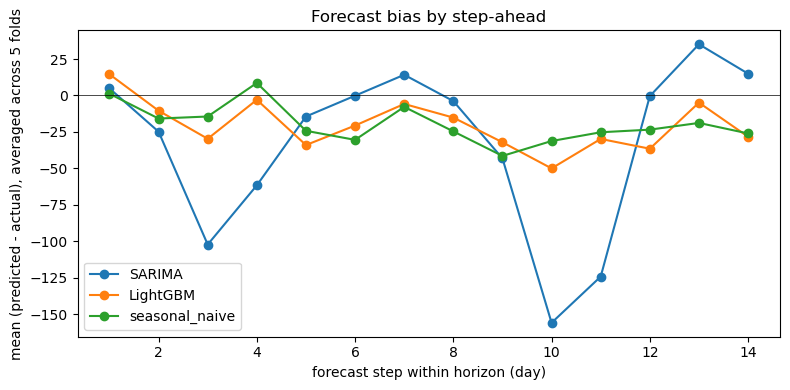

SARIMA bias, step 1 vs step 14: 4.856639990130168 vs 14.95359923567553


In [20]:
def per_step_bias(results, horizon=14):
    """Mean (predicted - actual) at each step 1..horizon, averaged across folds —
    shows whether error grows over the forecast horizon rather than staying flat."""
    step_errors = np.zeros(horizon)
    for r in results:
        step_errors += (r["y_pred"] - r["y_true"])
    return step_errors / len(results)

sarima_bias = per_step_bias(results_sarima)
lgbm_bias = per_step_bias(results_lgbm)
naive_bias = per_step_bias(results_baseline)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 15), sarima_bias, marker="o", label="SARIMA")
ax.plot(range(1, 15), lgbm_bias, marker="o", label="LightGBM")
ax.plot(range(1, 15), naive_bias, marker="o", label="seasonal_naive")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("forecast step within horizon (day)")
ax.set_ylabel("mean (predicted - actual), averaged across 5 folds")
ax.legend()
ax.set_title("Forecast bias by step-ahead")
plt.tight_layout()
plt.show()

print("SARIMA bias, step 1 vs step 14:", sarima_bias[0], "vs", sarima_bias[-1])

Bias tells a different story, though. SARIMA's systematic bias dropped sharply with the Fourier terms — step 1: +4.9 units vs. +19.8 before; step 14: +15.0 vs. +86.2 before — even as its overall error (MASE) got worse. Less systematically wrong, but not more accurate: the extra variance the exog terms introduce outweighs the bias they remove, at least across 5 folds of a series this size.


## 6. Probabilistic Forecast

SARIMA's native `get_forecast().conf_int()` at the 80% level, scored across all 5 backtest folds.


In [21]:
NOMINAL_LEVEL = 0.80
alpha = 1 - NOMINAL_LEVEL

interval_true, interval_lower, interval_upper = [], [], []

for train_slice, test_slice in splits:
    y_train_fold = y.values[train_slice]
    y_true_fold = y.values[test_slice]
    horizon = test_slice.stop - test_slice.start

    model = SARIMAX(
        y_train_fold,
        exog=annual_fourier(y.index[train_slice]),
        order=(1, 0, 1),
        seasonal_order=(1, 0, 0, 7),
        trend="c",
    )
    fit = model.fit(disp=False, maxiter=200)
    ci = np.asarray(fit.get_forecast(steps=horizon, exog=annual_fourier(y.index[test_slice])).conf_int(alpha=alpha))

    interval_true.append(y_true_fold)
    interval_lower.append(ci[:, 0])
    interval_upper.append(ci[:, 1])

interval_true = np.concatenate(interval_true)
interval_lower = np.concatenate(interval_lower)
interval_upper = np.concatenate(interval_upper)

cov = coverage(interval_true, interval_lower, interval_upper)
width = interval_width(interval_lower, interval_upper)

print(f"nominal level: {NOMINAL_LEVEL:.0%}")
print(f"empirical coverage: {cov:.3f}")
print(f"mean interval width: {width:.2f} units")

nominal level: 80%
empirical coverage: 0.986
mean interval width: 401.42 units


Still overcovering — 98.6% against an 80% target, better than the 100% the no-exog version gave but not calibrated — and still wide. SARIMA's RMSE here is 77.8; a well-calibrated 80% interval should have a half-width near 1.28×RMSE ≈ 100, i.e. a full width near 200. The actual width is 401, roughly double that, which is exactly why it overcovers. Same root cause as section 2: `sigma2` is inflated by residual structure the model never fully cleared.


### A conformal interval for LightGBM

SARIMA gets an interval for free from its state-space form; LightGBM doesn't. Backtest-conformal fixes that without extra machinery. A single held-out fold is only 14 points, too noisy to trust, so this calibrates leave-one-fold-out instead: for each fold, take the 80th percentile of the absolute errors LightGBM made on the *other four* folds as a fixed margin, apply it to that fold's own predictions, and pool coverage across all 5 folds (70 points instead of 14).


In [22]:
conformal_true, conformal_lower, conformal_upper = [], [], []

for i, test_fold in enumerate(results_lgbm):
    calib_folds = [r for j, r in enumerate(results_lgbm) if j != i]
    calib_abs_resid = np.concatenate([np.abs(r["y_true"] - r["y_pred"]) for r in calib_folds])
    margin = np.quantile(calib_abs_resid, NOMINAL_LEVEL)

    conformal_true.append(test_fold["y_true"])
    conformal_lower.append(test_fold["y_pred"] - margin)
    conformal_upper.append(test_fold["y_pred"] + margin)

conformal_true = np.concatenate(conformal_true)
conformal_lower = np.concatenate(conformal_lower)
conformal_upper = np.concatenate(conformal_upper)

conformal_cov = coverage(conformal_true, conformal_lower, conformal_upper)
conformal_width = interval_width(conformal_lower, conformal_upper)

print("LightGBM conformal interval (leave-one-fold-out calibration, all 5 folds pooled):")
print(f"  empirical coverage: {conformal_cov:.3f}")
print(f"  mean interval width: {conformal_width:.2f} units")


LightGBM conformal interval (leave-one-fold-out calibration, all 5 folds pooled):
  empirical coverage: 0.771
  mean interval width: 106.19 units


The conformal interval does what SARIMA's couldn't: 77.1% empirical coverage against an 80% target — close enough to call calibrated — at a mean width of 106 units, roughly a quarter of SARIMA's. Leave-one-fold-out pooling (70 points across all 5 folds) is doing real work here: the first version of this, calibrated on folds 0–3 and scored on just fold 4's 14 points, came out at a noisy, clearly-off 50% coverage — not wrong so much as not enough data to trust. The lesson isn't 'conformal beats analytic' in general; it's that *this* SARIMA's interval is inflated by exactly the residual structure flagged in section 2, while LightGBM's conformal margin is calibrated directly from its own backtest errors and doesn't inherit that problem.


## 7. Model Comparison & Recommendation


In [23]:
final_summary = summary.copy()
final_summary["beats_naive"] = final_summary["mase"] < summary.loc["seasonal_naive", "mase"]
print(final_summary)

print()
print(f"SARIMA 80% interval (analytic)   — empirical coverage: {cov:.1%}, mean width: {width:.1f} units")
print(f"LightGBM 80% interval (conformal) — empirical coverage: {conformal_cov:.1%}, mean width: {conformal_width:.1f} units")

                  mae   rmse  mase  beats_naive
model                                          
seasonal_naive  46.41  54.46  0.52        False
SARIMA          61.15  77.84  0.68        False
LightGBM        36.23  43.50  0.40         True

SARIMA 80% interval (analytic)   — empirical coverage: 98.6%, mean width: 401.4 units
LightGBM 80% interval (conformal) — empirical coverage: 77.1%, mean width: 106.2 units


**LightGBM** is the model I'd deploy for this series — more clearly now than it looked at first.

- **Accuracy** — it's the only model beating seasonal-naive (MASE 0.40 vs. 0.52). SARIMA, even after adding annual Fourier terms in section 2, ends up further behind naive (0.68) than it started (0.64) — the extra parameters helped in-sample (lower AIC) but didn't generalize across folds.
- **Interval support** — no longer SARIMA's exclusive advantage. Its analytic interval overcovers (98.6% vs. an 80% target) and is wide enough (401 units) to not be very useful — a symptom of the same residual structure that never fully cleared in section 2. LightGBM's leave-one-fold-out conformal interval, calibrated from its own backtest errors, comes in at 77.1% coverage — close to nominal — and a quarter of the width (106 units).
- **Interpretability** — SARIMA's coefficients are still the more directly readable artifact (`ar.S.L7=0.57` is literally "how much of last week repeats"); LightGBM's split-count importances (section 3: `lag_1` used in 449 splits, far more than anything else) are a reasonable substitute for a series where the operational question is *how much, when* rather than *why*.
- **History length & compute** — both trained fine on the available history and neither was expensive; SARIMA needed the most hands-on iteration (three fit attempts across section 2, only a partial payoff), LightGBM's pipeline stayed mechanical throughout, backtest included.

Net: LightGBM, for both the point forecast and the interval. The one thing SARIMA still offers is a directly-interpretable structural model — worth keeping around as a sanity check on the LightGBM/conformal pipeline, not as the deployed forecaster.
